# Fama-French Model Demo

This notebook ties together the three factor-model analyzers in `fama_french/model/`:

- CAPM: market-only benchmark
- Fama-French 3-factor model: market, size, and value
- Fama-French 5-factor model: market, size, value, profitability, and investment

This notebook imports the analyzers from `fama_french/model/` and csv results from `fama_french/output/`. The tables and charts compare the same assets across CAPM, FF3, and FF5.

In [16]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "output"
MODEL_DIR = BASE_DIR / "model"

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from model.capm import CAPMAnalyzer
from model.ff3 import FamaFrench3Analyzer
from model.ff5 import FamaFrench5Analyzer

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

OUTPUT_DIR.exists(), MODEL_DIR.exists()

(True, True)

## Load the shared data and model outputs

The next cell loads the merged factor dataset together with the CSV outputs generated by each model. This keeps the notebook self-contained and reproducible even when the raw data fetch is not rerun.

In [17]:
data = pd.read_csv(OUTPUT_DIR / "fama_french.csv")
capm_in_sample = pd.read_csv(OUTPUT_DIR / "capm_in_sample_daily.csv")
ff3_in_sample = pd.read_csv(OUTPUT_DIR / "ff3_in_sample_daily.csv")
ff5_in_sample = pd.read_csv(OUTPUT_DIR / "ff5_in_sample_daily.csv")

capm_oos = pd.read_csv(OUTPUT_DIR / "capm_out_of_sample.csv")
ff3_oos = pd.read_csv(OUTPUT_DIR / "ff3_out_of_sample.csv")
ff5_oos = pd.read_csv(OUTPUT_DIR / "ff5_out_of_sample.csv")
ff3_sig = pd.read_csv(OUTPUT_DIR / "ff3_factor_significance.csv")
ff5_comp = pd.read_csv(OUTPUT_DIR / "ff5_model_comparison.csv")

capm = CAPMAnalyzer()
ff3 = FamaFrench3Analyzer()
ff5 = FamaFrench5Analyzer()

print(f"Merged data shape: {data.shape}")
print(f"CAPM in-sample rows: {len(capm_in_sample)}")
print(f"FF3 in-sample rows: {len(ff3_in_sample)}")
print(f"FF5 in-sample rows: {len(ff5_in_sample)}")

summary = pd.DataFrame(
    {
        "CAPM": [len(capm.all_assets), capm.df.shape[0]],
        "FF3": [len(ff3.all_assets), ff3.df.shape[0]],
        "FF5": [len(ff5.all_assets), ff5.df.shape[0]],
    },
    index=["Assets", "Observations"],
)

display(summary)

INFO:model.capm:Loading CAPM data...
INFO:model.capm:  Loaded 1205 daily observations
INFO:model.capm:  Loaded 0 monthly observations
INFO:model.capm:  Assets: BAC, BLK, CG, CME, JPM, MET, MS, Portfolio_EQ, Portfolio_EQ_Excess
INFO:model.ff3:Loading Fama-French 3-Factor data...
INFO:model.ff3:  Loaded 1205 daily observations
INFO:model.ff3:  Loaded 0 monthly observations
INFO:model.ff3:  Assets: BAC, BLK, CG, CME, JPM, MET, MS, Portfolio_EQ, Portfolio_EQ_Excess
INFO:model.ff5:Loading Fama-French 5-Factor data...
INFO:model.ff5:  Loaded 1205 daily observations
INFO:model.ff5:  Loaded 0 monthly observations
INFO:model.ff5:  Assets: BAC, BLK, CG, CME, JPM, MET, MS, Portfolio_EQ, Portfolio_EQ_Excess


Merged data shape: (1205, 24)
CAPM in-sample rows: 8
FF3 in-sample rows: 8
FF5 in-sample rows: 8


,CAPM,FF3,FF5
Assets,9,9,9
Observations,1205,1205,1205


## Model comparison

CAPM gives the baseline benchmark. FF3 adds size and value, while FF5 adds profitability and investment. The key question is whether the extra factors materially improve fit without making the interpretation harder.

In [18]:
comparison = (
    capm_in_sample[["Asset", "R_Squared", "Sharpe_Ratio", "Jensens_Alpha", "Beta"]]
    .rename(
        columns={
            "R_Squared": "CAPM_R2",
            "Sharpe_Ratio": "CAPM_Sharpe",
            "Jensens_Alpha": "CAPM_Alpha",
            "Beta": "CAPM_Beta",
        }
    )
    .merge(
        ff3_in_sample[["Asset", "R_Squared", "Sharpe_Ratio", "Jensens_Alpha", "Beta_Mkt", "Beta_SMB", "Beta_HML"]]
        .rename(
            columns={
                "R_Squared": "FF3_R2",
                "Sharpe_Ratio": "FF3_Sharpe",
                "Jensens_Alpha": "FF3_Alpha",
            }
        ),
        on="Asset",
    )
    .merge(
        ff5_in_sample[["Asset", "R_Squared", "Sharpe_Ratio", "Jensens_Alpha", "Beta_Mkt", "Beta_SMB", "Beta_HML", "Beta_RMW", "Beta_CMA"]]
        .rename(
            columns={
                "R_Squared": "FF5_R2",
                "Sharpe_Ratio": "FF5_Sharpe",
                "Jensens_Alpha": "FF5_Alpha",
            }
        ),
        on="Asset",
        suffixes=("_FF3", "_FF5"),
    )
)

comparison = comparison[[
    "Asset",
    "CAPM_R2",
    "FF3_R2",
    "FF5_R2",
    "CAPM_Alpha",
    "FF3_Alpha",
    "FF5_Alpha",
    "CAPM_Sharpe",
    "FF3_Sharpe",
    "FF5_Sharpe",
    "CAPM_Beta",
    "Beta_Mkt_FF3",
    "Beta_Mkt_FF5",
]]

display(comparison.sort_values("FF5_R2", ascending=False).round(4))

,Asset,CAPM_R2,FF3_R2,FF5_R2,CAPM_Alpha,FF3_Alpha,FF5_Alpha,CAPM_Sharpe,FF3_Sharpe,FF5_Sharpe,CAPM_Beta,Beta_Mkt_FF3,Beta_Mkt_FF5
6,Portfolio_EQ,0.0269,0.0382,0.0385,-0.0313,-0.0326,-0.0322,-0.1617,-0.1617,-0.1617,0.0501,0.0545,0.0547
3,BAC,0.0215,0.0356,0.0364,-0.0331,-0.0355,-0.0351,-0.1350,-0.1350,-0.1350,0.0559,0.0631,0.0637
4,BLK,0.0314,0.0344,0.0356,-0.0339,-0.0348,-0.0344,-0.1387,-0.1387,-0.1387,0.0655,0.0684,0.0685
0,CG,0.0289,0.0335,0.0342,-0.0357,-0.0341,-0.0343,-0.0886,-0.0886,-0.0886,0.0945,0.0941,0.0937
5,MET,0.0068,0.0291,0.0303,-0.0311,-0.0342,-0.0334,-0.1443,-0.1443,-0.1443,0.0301,0.0390,0.0396
2,JPM,0.0180,0.0293,0.0297,-0.0284,-0.0305,-0.0299,-0.1301,-0.1301,-0.1301,0.0461,0.0521,0.0526
1,MS,0.0169,0.0244,0.0246,-0.0284,-0.0289,-0.0285,-0.1088,-0.1088,-0.1088,0.0521,0.0552,0.0556
7,CME,0.0005,0.0016,0.0031,-0.0285,-0.0301,-0.0300,-0.1877,-0.1877,-0.1877,0.0063,0.0092,0.0091


## 4. Visualize the Market vs. asset <a name="visualize"></a>

This section starts with the most direct relationship in the project: how one asset moves with the market factor. The four plots below show the short-run trend, the CAPM scatter fit, the rolling correlation, and the cumulative excess-return path for a representative asset.

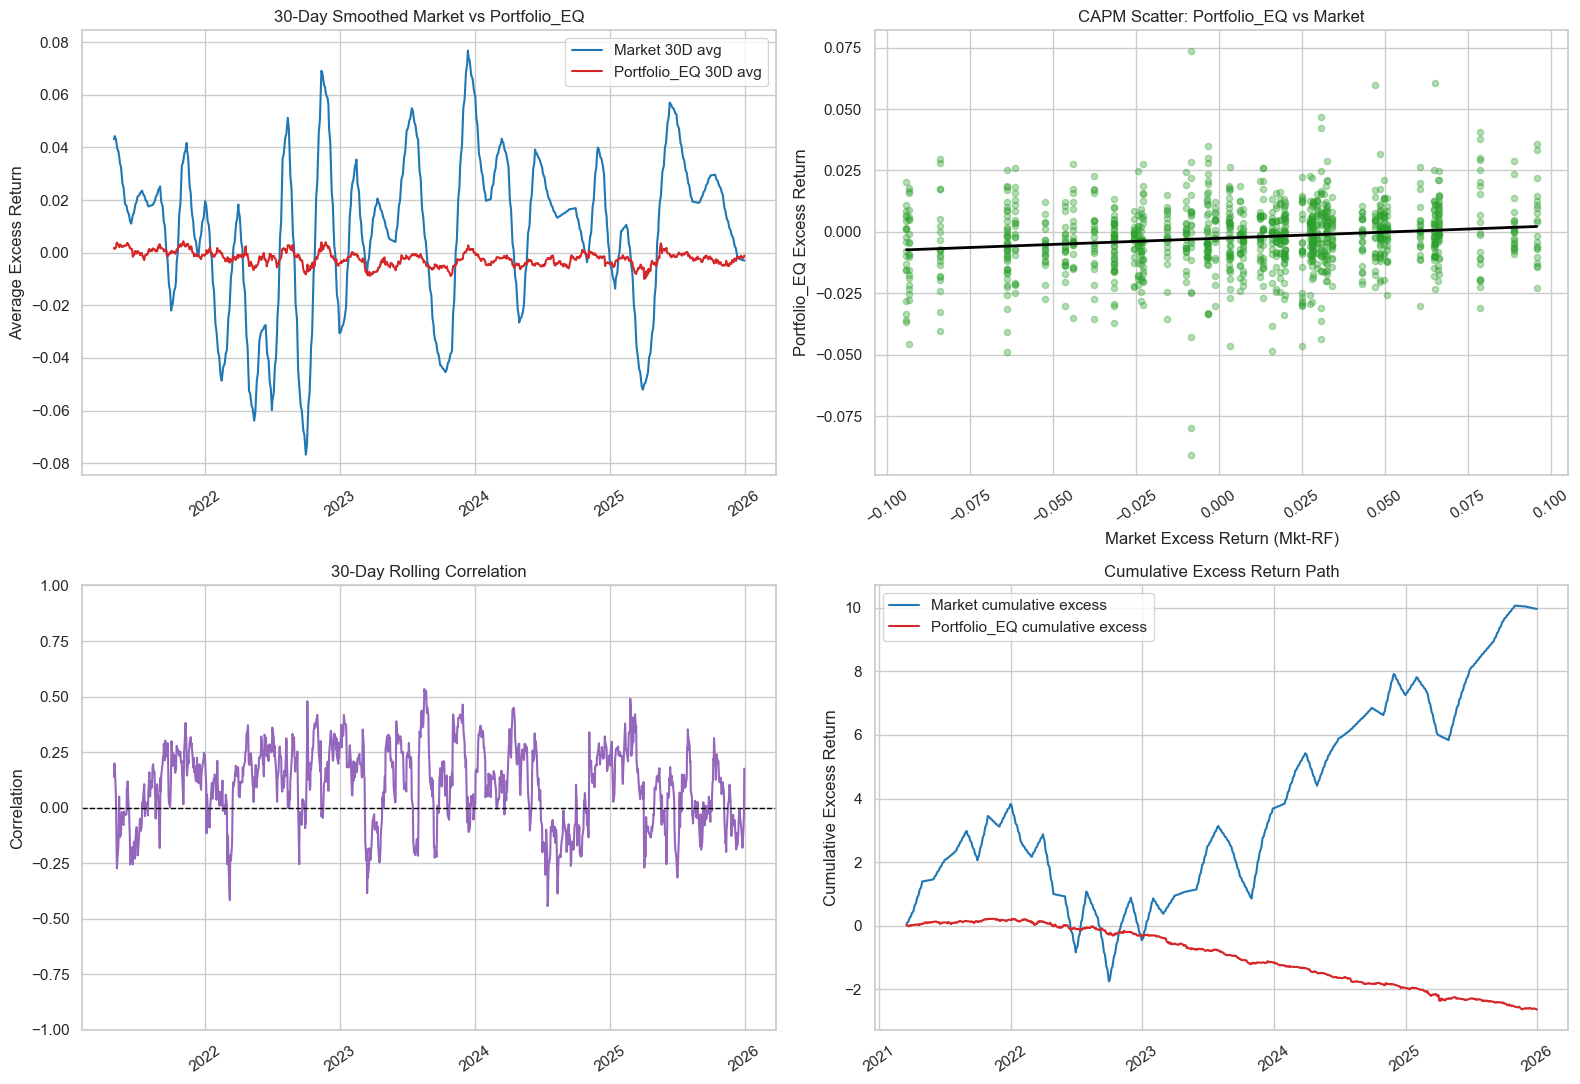

,Asset,Market_Asset_Corr,CAPM_Beta_Estimate,Mean_Market_Return,Mean_Asset_Return
0,Portfolio_EQ,0.1642,0.0501,0.0083,-0.0022


In [19]:
daily = data[data["Frequency"] == "Daily"].copy()
daily["Date"] = pd.to_datetime(daily["Date"])

asset_name = "Portfolio_EQ" if "Portfolio_EQ_Excess" in daily.columns else capm.all_assets[0]
asset_column = f"{asset_name}_Excess"

plot_df = daily[["Date", "Mkt-RF", asset_column]].dropna().copy()
plot_df["Market_30D"] = plot_df["Mkt-RF"].rolling(30).mean()
plot_df["Asset_30D"] = plot_df[asset_column].rolling(30).mean()
plot_df["Rolling_Corr_30D"] = plot_df["Mkt-RF"].rolling(30).corr(plot_df[asset_column])
plot_df["Market_Cum"] = plot_df["Mkt-RF"].cumsum()
plot_df["Asset_Cum"] = plot_df[asset_column].cumsum()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

axes[0, 0].plot(plot_df["Date"], plot_df["Market_30D"], label="Market 30D avg", color="#1f77b4")
axes[0, 0].plot(plot_df["Date"], plot_df["Asset_30D"], label=f"{asset_name} 30D avg", color="#d62728")
axes[0, 0].set_title(f"30-Day Smoothed Market vs {asset_name}")
axes[0, 0].set_ylabel("Average Excess Return")
axes[0, 0].legend()

x_vals = plot_df["Mkt-RF"].values
y_vals = plot_df[asset_column].values
beta_1, beta_0 = np.polyfit(x_vals, y_vals, 1)
line_x = np.linspace(x_vals.min(), x_vals.max(), 100)
line_y = beta_1 * line_x + beta_0

axes[0, 1].scatter(x_vals, y_vals, alpha=0.35, s=20, color="#2ca02c")
axes[0, 1].plot(line_x, line_y, color="black", linewidth=2)
axes[0, 1].set_title(f"CAPM Scatter: {asset_name} vs Market")
axes[0, 1].set_xlabel("Market Excess Return (Mkt-RF)")
axes[0, 1].set_ylabel(f"{asset_name} Excess Return")

axes[1, 0].plot(plot_df["Date"], plot_df["Rolling_Corr_30D"], color="#9467bd")
axes[1, 0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1, 0].set_title("30-Day Rolling Correlation")
axes[1, 0].set_ylabel("Correlation")
axes[1, 0].set_ylim(-1, 1)

axes[1, 1].plot(plot_df["Date"], plot_df["Market_Cum"], label="Market cumulative excess", color="#1f77b4")
axes[1, 1].plot(plot_df["Date"], plot_df["Asset_Cum"], label=f"{asset_name} cumulative excess", color="#d62728")
axes[1, 1].set_title("Cumulative Excess Return Path")
axes[1, 1].set_ylabel("Cumulative Excess Return")
axes[1, 1].legend()

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {
            "Asset": [asset_name],
            "Market_Asset_Corr": [plot_df["Mkt-RF"].corr(plot_df[asset_column])],
            "CAPM_Beta_Estimate": [beta_1],
            "Mean_Market_Return": [plot_df["Mkt-RF"].mean()],
            "Mean_Asset_Return": [plot_df[asset_column].mean()],
        }
    ).round(4)
)

## Visualizing the differences

The charts below show two things that matter most in practice: how much each model explains and how the factor exposures change as the model becomes richer.

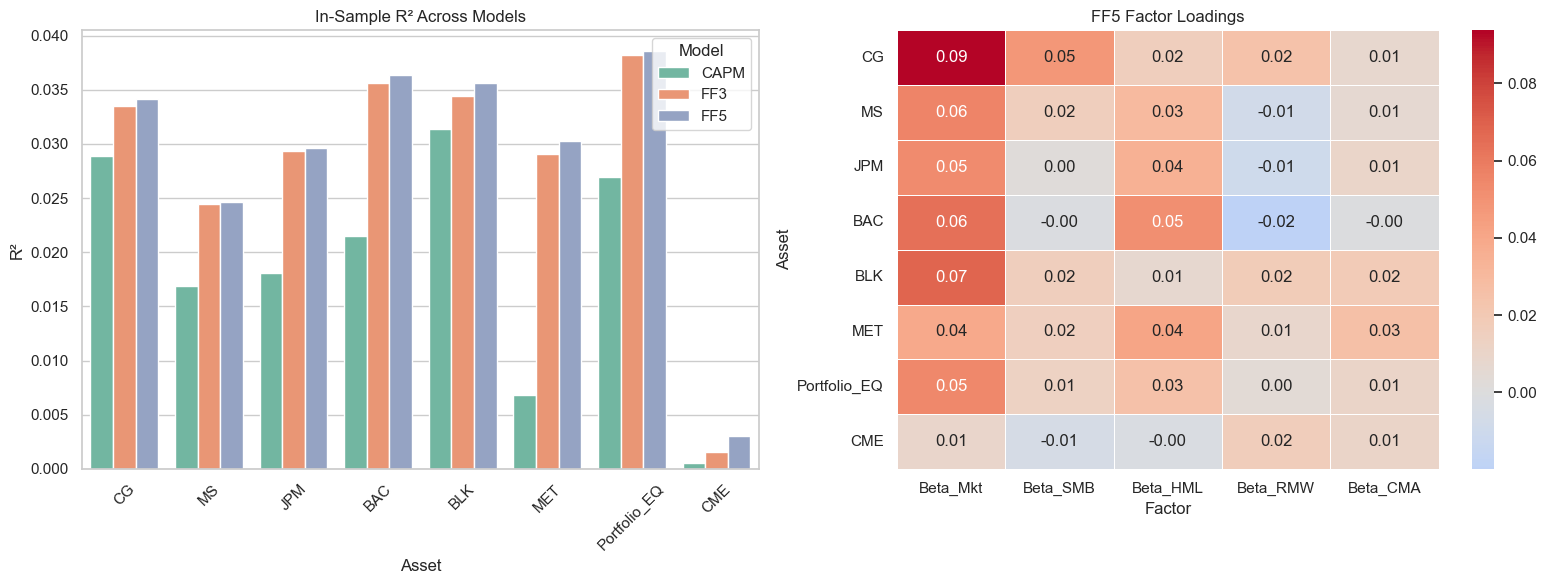

,Asset,CAPM_R2,FF3_R2,FF5_R2,FF5_over_FF3,FF5_Better_than_FF3
7,Portfolio_EQ,0.0269,0.0382,0.0385,0.0003,True
0,BAC,0.0215,0.0356,0.0364,0.0008,True
1,BLK,0.0314,0.0344,0.0356,0.0012,True
2,CG,0.0289,0.0335,0.0342,0.0006,True
5,MET,0.0068,0.0291,0.0303,0.0012,True
4,JPM,0.0180,0.0293,0.0297,0.0003,True
6,MS,0.0169,0.0244,0.0246,0.0002,True
3,CME,0.0005,0.0016,0.0031,0.0015,True


,Asset,F_Stat_SMB_HML,F_pval_SMB_HML,SMB_Significant,HML_Significant
5,MET,13.7722,0.0000,True,True
0,BAC,8.7937,0.0002,True,True
7,Portfolio_EQ,7.0390,0.0009,True,True
4,JPM,6.9699,0.0010,True,True
6,MS,4.6396,0.0098,True,True
2,CG,2.8980,0.0555,False,False
1,BLK,1.8901,0.1515,False,False
3,CME,0.6510,0.5217,False,False


In [20]:
model_fit = comparison.melt(
    id_vars="Asset",
    value_vars=["CAPM_R2", "FF3_R2", "FF5_R2"],
    var_name="Model",
    value_name="R_Squared",
)
model_fit["Model"] = model_fit["Model"].str.replace("_R2", "", regex=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=model_fit,
    x="Asset",
    y="R_Squared",
    hue="Model",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("In-Sample R² Across Models")
axes[0].set_ylabel("R²")
axes[0].set_xlabel("Asset")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Model")

beta_map = ff5_in_sample.set_index("Asset")[["Beta_Mkt", "Beta_SMB", "Beta_HML", "Beta_RMW", "Beta_CMA"]]
sns.heatmap(
    beta_map,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title("FF5 Factor Loadings")
axes[1].set_xlabel("Factor")
axes[1].set_ylabel("Asset")

plt.tight_layout()
plt.show()

display(
    ff5_comp[["Asset", "CAPM_R2", "FF3_R2", "FF5_R2", "FF5_over_FF3", "FF5_Better_than_FF3"]]
    .sort_values("FF5_R2", ascending=False)
    .round(4)
)

display(
    ff3_sig[["Asset", "F_Stat_SMB_HML", "F_pval_SMB_HML", "SMB_Significant", "HML_Significant"]]
    .sort_values("F_pval_SMB_HML")
    .round(4)
)

## 5. Robustness Check

A good demo should not stop at one sample period. The checks below compare the first half and second half of the sample, then contrast out-of-sample RMSE across models. That makes the project easier to trust because it shows whether the main conclusions survive a simple stress test.

In [ ]:
daily = data[data["Frequency"] == "Daily"].copy()
daily["Date"] = pd.to_datetime(daily["Date"])
daily = daily.sort_values("Date")
split_date = daily["Date"].iloc[len(daily) // 2]
first_half = daily[daily["Date"] <= split_date].copy()
second_half = daily[daily["Date"] > split_date].copy()

asset_name = "Portfolio_EQ" if "Portfolio_EQ_Excess" in daily.columns else capm.all_assets[0]
asset_column = f"{asset_name}_Excess"

def fit_simple_capm(frame):
    subset = frame[["Mkt-RF", asset_column]].dropna()
    slope, intercept = np.polyfit(subset["Mkt-RF"], subset[asset_column], 1)
    fitted = intercept + slope * subset["Mkt-RF"]
    ss_res = ((subset[asset_column] - fitted) ** 2).sum()
    ss_tot = ((subset[asset_column] - subset[asset_column].mean()) ** 2).sum()
    return {
        "beta": slope,
        "alpha": intercept,
        "r2": 1 - ss_res / ss_tot if ss_tot != 0 else np.nan,
    }

first_fit = fit_simple_capm(first_half)
second_fit = fit_simple_capm(second_half)

robustness_summary = pd.DataFrame({
    "Metric": ["CAPM Beta", "CAPM Alpha", "CAPM R²", "FF3 Mean OOS RMSE", "FF5 Mean OOS RMSE"],
    "First_Half": [first_fit["beta"], first_fit["alpha"], first_fit["r2"], np.nan, np.nan],
    "Second_Half": [second_fit["beta"], second_fit["alpha"], second_fit["r2"], np.nan, np.nan],
    "Model_Avg": [np.nan, np.nan, np.nan, ff3_oos["mean_rmse"].mean(), ff5_oos["mean_rmse"].mean()],
}).round(4)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

beta_df = pd.DataFrame({
    "Sample": ["First half", "Second half"],
    "Beta": [first_fit["beta"], second_fit["beta"]],
    "Alpha": [first_fit["alpha"], second_fit["alpha"]],
    "R2": [first_fit["r2"], second_fit["r2"]],
})
beta_long = beta_df.melt(id_vars="Sample", var_name="Metric", value_name="Value")
sns.barplot(data=beta_long, x="Sample", y="Value", hue="Metric", ax=axes[0], palette="Set3")
axes[0].set_title(f"CAPM Stability for {asset_name}")
axes[0].set_ylabel("Estimate")
axes[0].set_xlabel("Sample Split")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Metric")

oos_df = pd.DataFrame({
    "Asset": ff3_oos["Asset"],
    "FF3_RMSE": ff3_oos["mean_rmse"],
    "FF5_RMSE": ff5_oos["mean_rmse"],
})
oos_long = oos_df.melt(id_vars="Asset", var_name="Model", value_name="RMSE")
sns.barplot(data=oos_long, x="Asset", y="RMSE", hue="Model", ax=axes[1], palette="muted")
axes[1].set_title("Out-of-Sample RMSE by Asset")
axes[1].set_ylabel("Mean RMSE")
axes[1].set_xlabel("Asset")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Model")

plt.tight_layout()
plt.show()

display(robustness_summary)

## Closing note

The integrated view is intentionally simple: CAPM is the benchmark, FF3 usually improves the fit by adding size and value, and FF5 adds two more dimensions that tighten the explanation a bit further. The notebook now mirrors the reorganized project structure, with the analyzers in `model/` and all CSV artifacts in `output/`.